<a href="https://colab.research.google.com/github/efpha/Reinforced-Deep-Learning/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK 2: LSTM — Stock Trend Prediction**

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

**Data preprocessing**

In [2]:
data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
close_prices = data['Close'].values.reshape(-1,1)

/tmp/ipykernel_5243/2119110083.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


**Normalize & Create Sequence**

In [3]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(close_prices)

def create_sequences(data, seq_length=15):
    X, y = [], []

    for i in range(len(data) - seq_length - 1):
        X.append(data[i:i+seq_length])

        # Binary label: 1 = up, 0 = down
        label = 1 if data[i+seq_length] > data[i+seq_length-1] else 0
        y.append(label)

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 15)

**Train Test Split**

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, shuffle=False
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, shuffle=False
)

**Build Model**

In [5]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(15,1)),
    Dropout(0.2),

    LSTM(50),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Compile Model**

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**Train Model**

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5168 - loss: 0.6927 - val_accuracy: 0.5163 - val_loss: 0.6941
Epoch 2/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5308 - loss: 0.6918 - val_accuracy: 0.5163 - val_loss: 0.6939
Epoch 3/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5308 - loss: 0.6916 - val_accuracy: 0.5163 - val_loss: 0.6931
Epoch 4/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5308 - loss: 0.6920 - val_accuracy: 0.5163 - val_loss: 0.6928
Epoch 5/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5308 - loss: 0.6920 - val_accuracy: 0.5163 - val_loss: 0.6930
Epoch 6/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5308 - loss: 0.6918 - val_accuracy: 0.5163 - val_loss: 0.6943
Epoch 7/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5308 - loss: 0.6916 - val_accuracy: 0.5163 - val_loss: 0.6935
Epoch 8/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5308 - loss: 0.6915 - val_accuracy: 0.5163 - val_loss

**Evaluation**

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5296 - loss: 0.6915
Test Accuracy: 0.5295857787132263


**Plots**

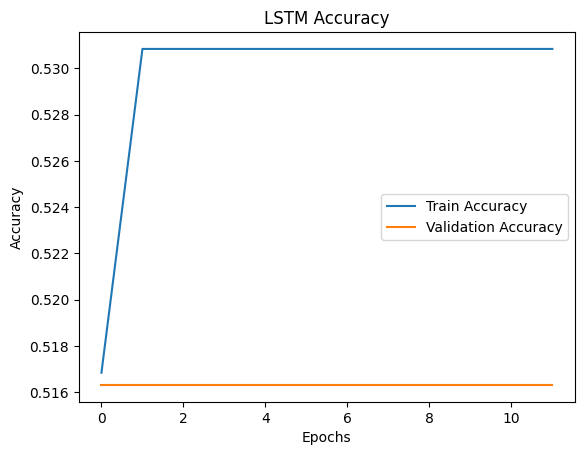

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("LSTM Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

**Predictions and Metrics**

In [10]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Confusion Matrix:
[[  0 159]
 [  0 179]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       159
           1       0.53      1.00      0.69       179

    accuracy                           0.53       338
   macro avg       0.26      0.50      0.35       338
weighted avg       0.28      0.53      0.37       338



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**BaseLine Comparisson**

In [11]:
baseline_pred = np.ones_like(y_test)

baseline_acc = accuracy_score(y_test, baseline_pred)

print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.5295857988165681
